# The "Mini-Project": A Simple Backtester

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
returns = np.random.normal(0.001, 0.02, 500)
close_prices = 100 * (1 + returns).cumprod()

df = pd.DataFrame({
    'Close': close_prices
}, index=pd.date_range(start='2020-01-01', periods=500, freq='B'))


In [2]:
df.head()

,Close
2020-01-01,101.093428
2020-01-02,100.914969
2020-01-03,102.323114
2020-01-06,105.542260
2020-01-07,105.153541


# Calculating 50MA and 200MA

In [3]:
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

df.tail()

,Close,MA_50,MA_200
2021-11-24,171.389512,161.895588,154.628267
2021-11-25,168.005439,161.808621,154.874973
2021-11-26,167.533886,161.773573,155.115080
2021-11-29,164.767505,161.714608,155.331043
2021-11-30,160.375464,161.635507,155.516784


# Generate buy/sell signals when they cross

In [4]:
#df['Signal'] = np.where(df['MA_50'] > df['MA_200'], 'BUY', 'SELL')
#df['Signal'] = np.where(df['MA_50'] > df['MA_200'], 'BUY', np.where(df['MA_50'] < df['MA_200'], 'SELL', 'None'))

df['Signal'] = 0
df['Signal'] = np.where(df['MA_50'] > df['MA_200'], 1, -1) # 1 for Buy and -1 for Sell

df.tail()

,Close,MA_50,MA_200,Signal
2021-11-24,171.389512,161.895588,154.628267,1
2021-11-25,168.005439,161.808621,154.874973,1
2021-11-26,167.533886,161.773573,155.115080,1
2021-11-29,164.767505,161.714608,155.331043,1
2021-11-30,160.375464,161.635507,155.516784,1


# Calculate Return

In [5]:
df['Return'] = df['Close'].pct_change()
df['Sys_Return'] = df['Signal'].shift(1) * df['Return'] # shift(1) avoids lookahead bias!

df.tail()

,Close,MA_50,MA_200,Signal,Return,Sys_Return
2021-11-24,171.389512,161.895588,154.628267,1,0.011778,0.011778
2021-11-25,168.005439,161.808621,154.874973,1,-0.019745,-0.019745
2021-11-26,167.533886,161.773573,155.115080,1,-0.002807,-0.002807
2021-11-29,164.767505,161.714608,155.331043,1,-0.016512,-0.016512
2021-11-30,160.375464,161.635507,155.516784,1,-0.026656,-0.026656


# Calculate Sharpe Ratio

In [6]:
Sharpe_ratio = df['Sys_Return'].mean() / df['Sys_Return'].std()
print(Sharpe_ratio)

0.051563455610650774


# The Plot

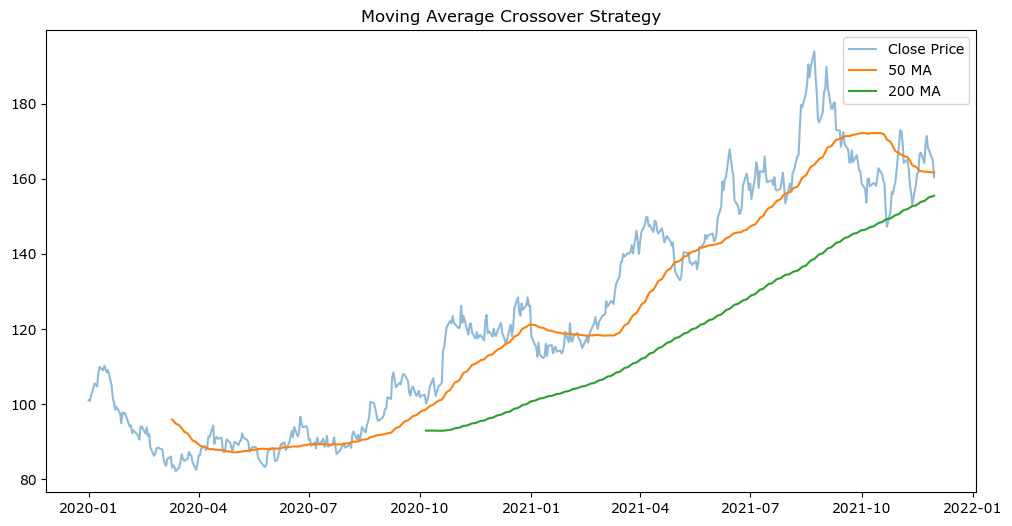

In [23]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price', alpha=0.5)
plt.plot(df['MA_50'], label='50 MA')
plt.plot(df['MA_200'], label='200 MA')

plt.legend()
plt.title('Moving Average Crossover Strategy')
plt.show()